# Failure Classification Modeling

This notebook presents the development of a machine learning model for predicting failures.

In [221]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sqlalchemy import create_engine
from local_settings import postgres_url as url_dict
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.base import BaseEstimator, TransformerMixin
from feature_engine import discretisation, encoding
from sklearn import metrics, pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

%matplotlib inline

In [128]:
# Load 'milling_pdm_celsius' dataset to a pandas dataframe
url = f"postgresql+psycopg2://{url_dict['pguser']}:{url_dict['pgpasswd']}@{url_dict['pghost']}/{url_dict['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df

,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


## Sample

In [7]:
# Prepare analytical table
columns = ['product_type', 'air_temperature_celsius', 'process_temperature_celsius',
            'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure']

df_abt = df.loc[:, columns]
df_abt

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
register_id,,,,,,,
1,M,24.950006,35.450006,1551.0,42.8,0,False
2,L,25.050012,35.550012,1408.0,46.3,3,False
3,L,24.950006,35.350000,1498.0,49.4,5,False
4,L,25.050012,35.450006,1433.0,39.5,7,False
5,L,25.050012,35.550012,1408.0,40.0,9,False
...,...,...,...,...,...,...,...
9996,M,25.649988,35.249994,1604.0,29.5,14,False
9997,H,25.749994,35.249994,1632.0,31.8,17,False
9998,M,25.850000,35.450006,1645.0,33.4,22,False


In [10]:
# Split features and target
features = ['product_type', 'air_temperature_celsius', 'process_temperature_celsius',
            'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
target = 'machine_failure'

X = df.loc[:, features]
y = df.loc[:, target]

In [ ]:
# Train and test split
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

## Explore

### Prepare data for exploratory analysis

In [69]:
# Create EDA X and y
X_eda = X_train.copy()
y_eda = y_train.copy()

In [70]:
X_eda

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min
register_id,,,,,,
9070,M,24.050012,35.050012,1678.0,28.1,133
2604,M,26.149988,36.050012,1334.0,46.3,31
7739,M,27.350000,38.850000,1263.0,60.8,146
1580,L,25.149988,35.149988,1444.0,43.8,176
5059,L,30.749994,39.749994,1526.0,42.5,194
...,...,...,...,...,...,...
5735,L,29.149988,38.649988,1369.0,56.2,208
5192,L,30.850000,40.050012,1416.0,46.0,128
5391,H,29.649988,39.149988,1483.0,47.2,223


In [72]:
# Add Temperature Difference feature
X_eda['temp_diff_celsius'] = X_eda['process_temperature_celsius'] - X_eda['air_temperature_celsius']
X_eda.loc[:, ['process_temperature_celsius', 'air_temperature_celsius', 'temp_diff_celsius']].head(10)

,process_temperature_celsius,air_temperature_celsius,temp_diff_celsius
register_id,,,
9070,35.050012,24.050012,11.000000
2604,36.050012,26.149988,9.900024
7739,38.850000,27.350000,11.500000
1580,35.149988,25.149988,10.000000
5059,39.749994,30.749994,9.000000
5754,38.450006,29.050012,9.399994
3549,37.749994,28.749994,9.000000
410,35.450006,24.249994,11.200012
4098,37.249994,28.749994,8.500000


In [109]:
# Add Mechanical Power feature
X_eda['mech_power_kwatts'] = 2*np.pi * X_eda['rotational_speed_rpm'] * X_eda['torque_nm'] / 60000
X_eda.loc[:, ['rotational_speed_rpm', 'torque_nm', 'mech_power_kwatts']].head(10)

,rotational_speed_rpm,torque_nm,mech_power_kwatts
register_id,,,
9070,1678.0,28.1,4.937725
2604,1334.0,46.3,6.467932
7739,1263.0,60.8,8.041472
1580,1444.0,43.8,6.623231
5059,1526.0,42.5,6.791600
5754,1416.0,54.1,8.022120
3549,1616.0,34.5,5.838336
410,1459.0,41.3,6.310067
4098,1518.0,34.1,5.420692


### Check target class balance at train and test

In [21]:
# Check target classes balance in the ABT
y.value_counts(normalize=True)

machine_failure
False    0.9661
True     0.0339
Name: proportion, dtype: float64

In [19]:
# Check target class balance in train
y_train.value_counts(normalize=True)

machine_failure
False    0.964857
True     0.035143
Name: proportion, dtype: float64

In [20]:
# Check target class balance in test
y_test.value_counts(normalize=True)

machine_failure
False    0.969
True     0.031
Name: proportion, dtype: float64

### Evaluate feature mean difference for failure and non-failure conditions

In [110]:
df_mean_diff = pd.concat([X_train, y_train], axis=1).drop("product_type", axis=1)
df_mean_diff = df_mean_diff.groupby("machine_failure").agg(["mean", "median"]).T
df_mean_diff["diff"] =  np.abs ( (df_mean_diff[False] - df_mean_diff[True]) / df_mean_diff[True] )
df_mean_diff = df_mean_diff.sort_values(by="diff", ascending=False)

In [111]:
df_mean_diff

machine_failure                           False         True      diff
tool_wear_min               median   106.000000   165.500000  0.359517
                            mean     106.363340   143.390244  0.258225
torque_nm                   median    40.000000    53.400000  0.250936
                            mean      39.755315    49.820325  0.202026
rotational_speed_rpm        median  1505.000000  1364.000000  0.103372
air_temperature_celsius     median    26.950006    28.550012  0.056042
                            mean      26.825599    27.847561  0.036698
rotational_speed_rpm        mean    1539.384365  1496.500000  0.028656
process_temperature_celsius median    36.950006    37.350000  0.010709
                            mean      36.846802    37.188618  0.009191

### Evaluate feature importance using Decision Tree

#### Initial features

In [112]:
# Train decision tree
pd.set_option('future.no_silent_downcasting', True)
X_eda_tree = X_train.copy()
X_eda_tree['product_type'] = X_eda_tree['product_type'].replace({'L':1, 'M':2, 'H':3})
eda_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
eda_tree.fit(X=X_eda_tree, y=y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [114]:
# Feature importance
pd.Series(eda_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)

torque_nm                      0.450426
air_temperature_celsius        0.168187
rotational_speed_rpm           0.138957
tool_wear_min                  0.122242
process_temperature_celsius    0.116476
product_type                   0.003713
dtype: float64

#### Using new features

In [115]:
# Train decision tree
pd.set_option('future.no_silent_downcasting', True)
X_eda_tree = X_eda.copy()
X_eda_tree['product_type'] = X_eda_tree['product_type'].replace({'L':1, 'M':2, 'H':3})
eda_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
eda_tree.fit(X=X_eda_tree, y=y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

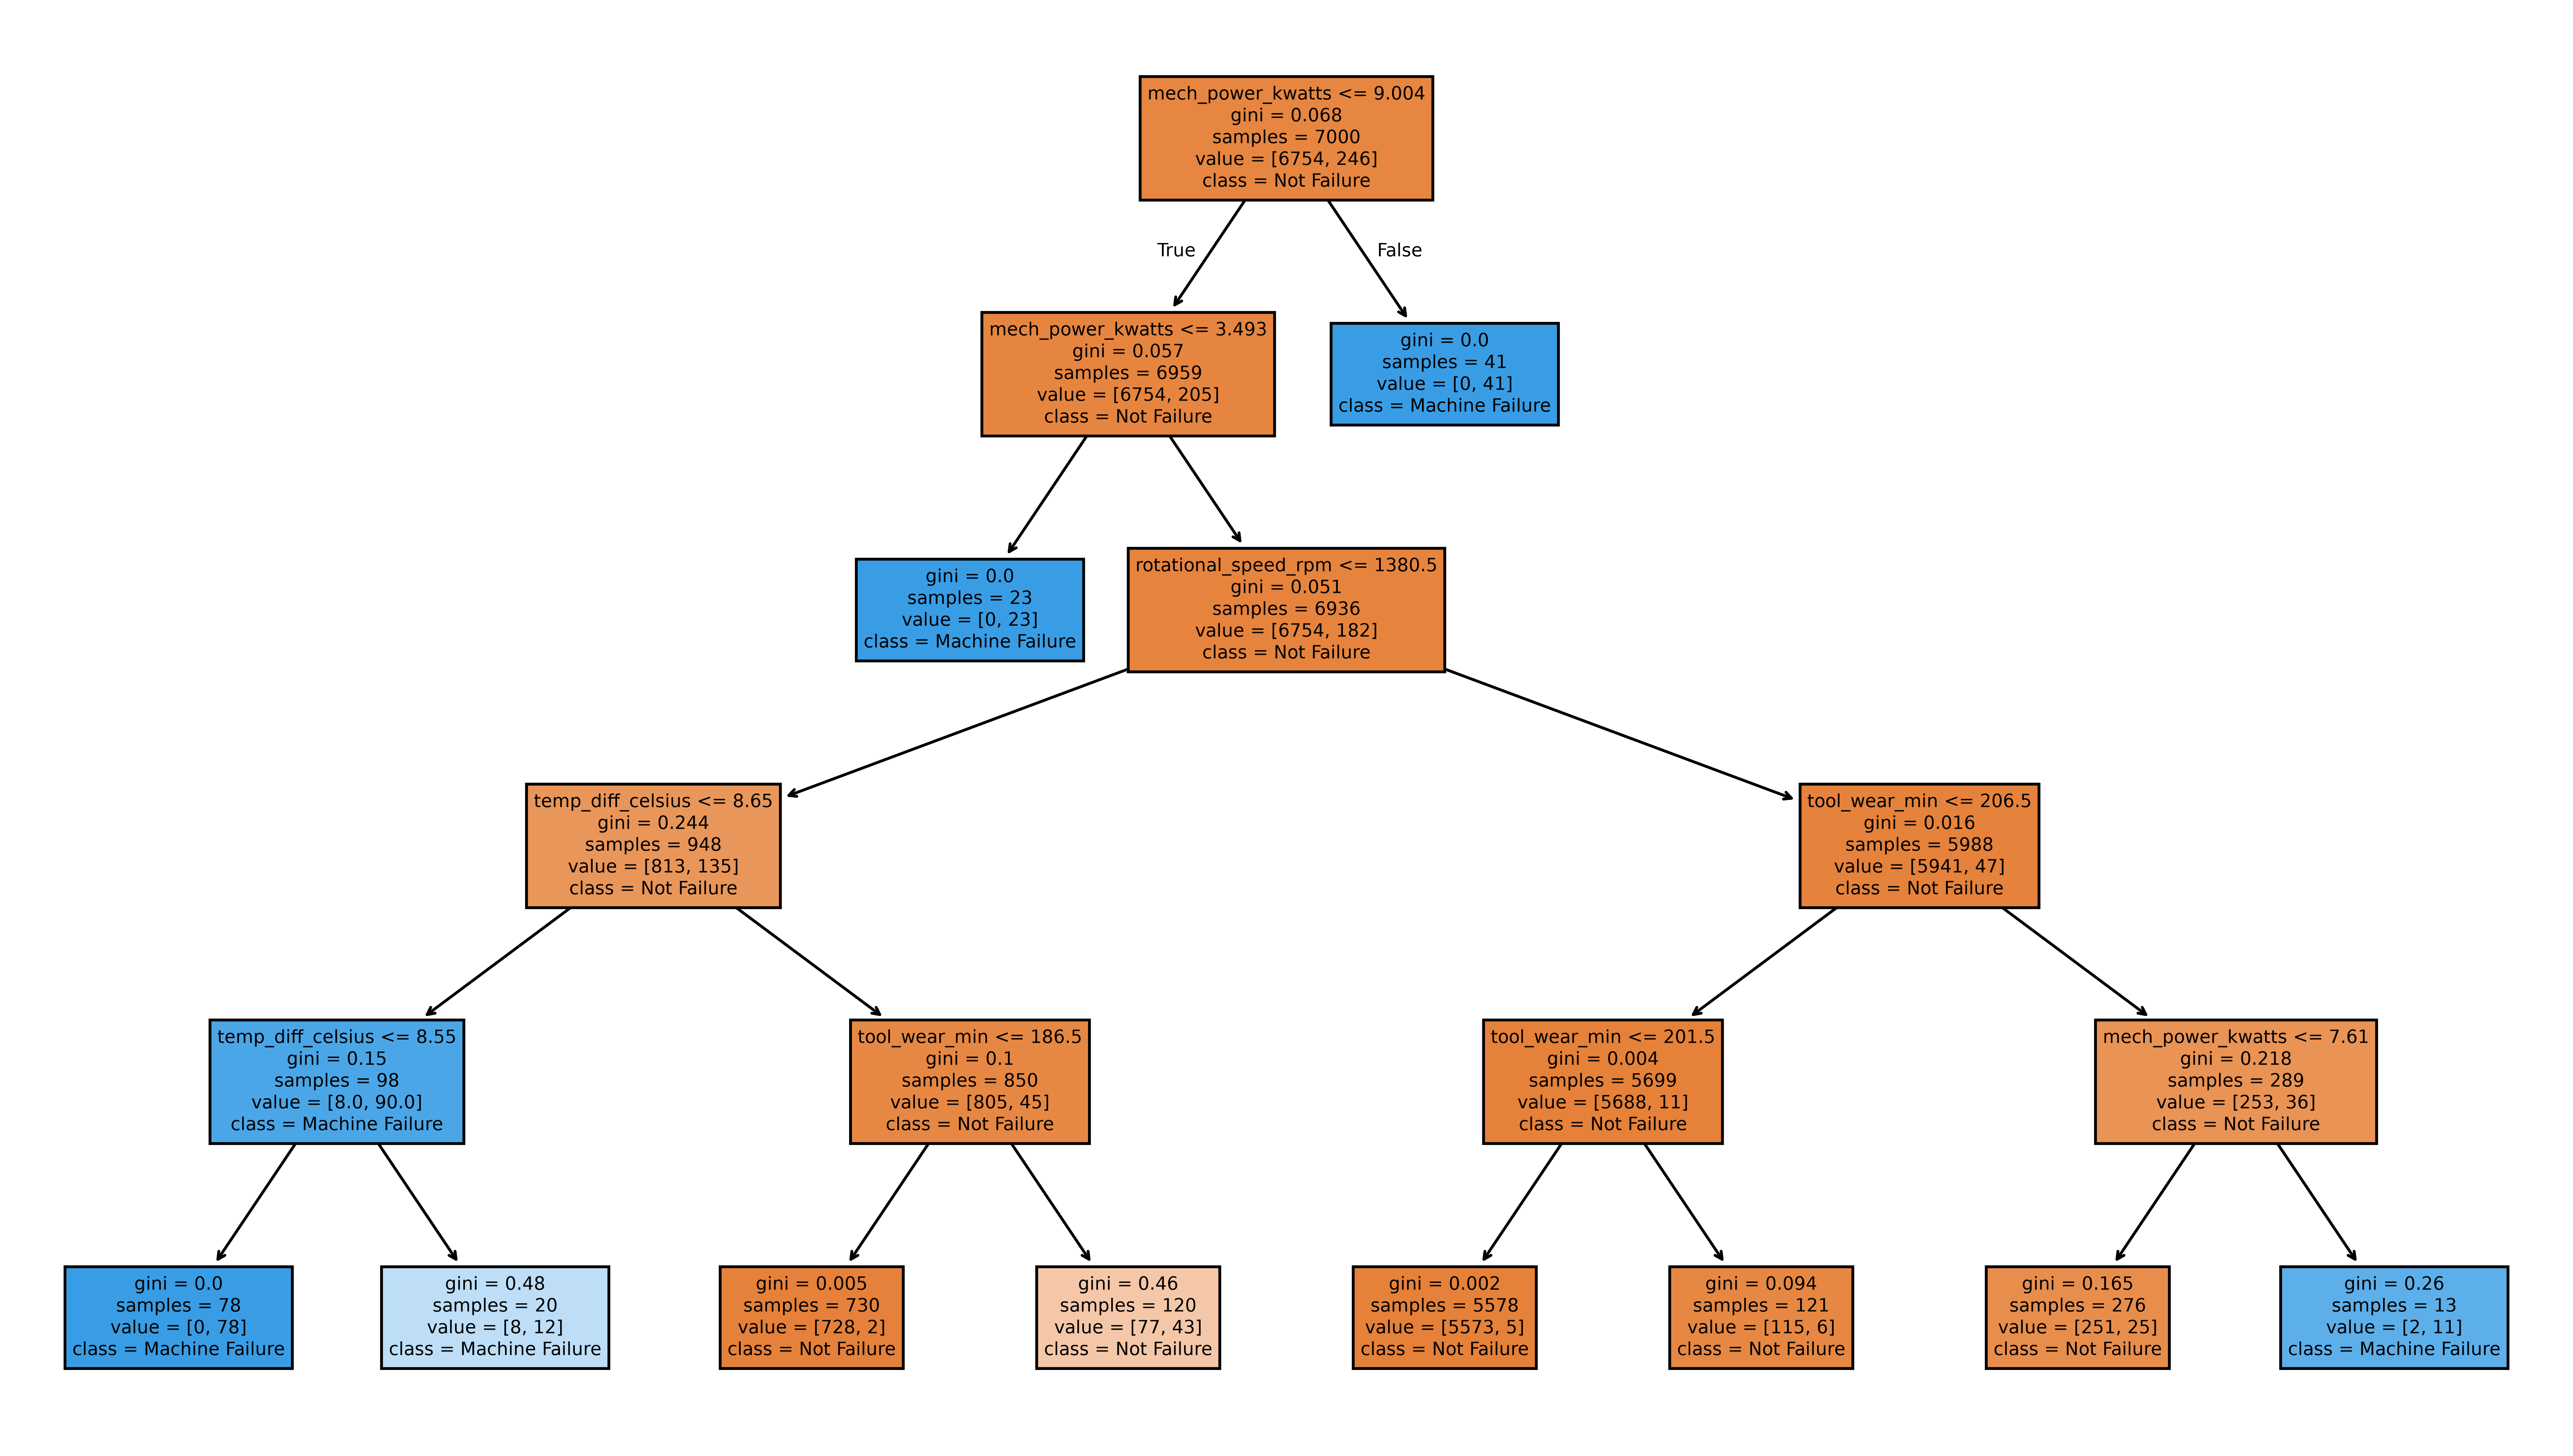

In [119]:
# Plot tree
plt.figure(dpi=600, figsize=(16,9))
plot_tree(eda_tree, filled=True, feature_names=X_eda.columns, class_names=["Not Failure", "Machine Failure"])
plt.show()

In [108]:
# Feature importance
pd.Series(eda_tree.feature_importances_, index=X_eda.columns).sort_values(ascending=False)

temp_diff_celsius              0.407272
mech_power_kwatts              0.400483
tool_wear_min                  0.103960
rotational_speed_rpm           0.088285
process_temperature_celsius    0.000000
air_temperature_celsius        0.000000
product_type                   0.000000
torque_nm                      0.000000
dtype: float64

## Modify

### Add new features to training

In [123]:
# Create class FeatureCreator for Feature Engineering
class FeatureCreator(BaseEstimator, TransformerMixin):
    """
    Pipeline step for adding new features derived from existing ones
    """
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        """
        Adding the following new features to the train data:
        
        - temp_diff_celsius (temperature difference)
        - mech_power_kwatts (mechanical power)
        
        """
        X_out = X.copy()
        X_out['temp_diff_celsius'] = X_out['process_temperature_celsius'] - X_out['air_temperature_celsius']
        X_out['mech_power_kwatts'] = 2*np.pi * X_out['rotational_speed_rpm'] * X_out['torque_nm'] / 60000
        
        return X_out

In [133]:
feat_eng = FeatureCreator()
feat_eng.transform(X_train)

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,temp_diff_celsius,mech_power_kwatts
register_id,,,,,,,,
9070,M,24.050012,35.050012,1678.0,28.1,133,11.000000,4.937725
2604,M,26.149988,36.050012,1334.0,46.3,31,9.900024,6.467932
7739,M,27.350000,38.850000,1263.0,60.8,146,11.500000,8.041472
1580,L,25.149988,35.149988,1444.0,43.8,176,10.000000,6.623231
5059,L,30.749994,39.749994,1526.0,42.5,194,9.000000,6.791600
...,...,...,...,...,...,...,...,...
5735,L,29.149988,38.649988,1369.0,56.2,208,9.500000,8.056908
5192,L,30.850000,40.050012,1416.0,46.0,128,9.200012,6.821026
5391,H,29.649988,39.149988,1483.0,47.2,223,9.500000,7.330132


### One-hot encoding of product types

In [129]:
onehot = encoding.OneHotEncoder(variables=['product_type'])

In [132]:
onehot.fit(X_train)
onehot.transform(X_train)

,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,product_type_M,product_type_L,product_type_H
register_id,,,,,,,,
9070,24.050012,35.050012,1678.0,28.1,133,1,0,0
2604,26.149988,36.050012,1334.0,46.3,31,1,0,0
7739,27.350000,38.850000,1263.0,60.8,146,1,0,0
1580,25.149988,35.149988,1444.0,43.8,176,0,1,0
5059,30.749994,39.749994,1526.0,42.5,194,0,1,0
...,...,...,...,...,...,...,...,...
5735,29.149988,38.649988,1369.0,56.2,208,0,1,0
5192,30.850000,40.050012,1416.0,46.0,128,0,1,0
5391,29.649988,39.149988,1483.0,47.2,223,0,0,1


### Numerical data discretisation

In [ ]:
# Create Decision Tree Discretiser
tree_desc = discretisation.DecisionTreeDiscretiser(
    variables= ['air_temperature_celsius', 'process_temperature_celsius', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min'],
    regression=False,
    cv=3,
    bin_output='bin_number'
)

In [139]:
tree_desc.fit(X_train, y_train)
X_tree_desc = tree_desc.transform(X_train)
X_tree_desc.head(10)

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min
register_id,,,,,,
9070,M,0,0,2,1,0
2604,M,0,0,1,1,0
7739,M,0,1,0,1,0
1580,L,0,0,2,1,0
5059,L,1,1,2,1,0
5754,L,1,1,2,1,0
3549,L,1,1,2,1,0
410,L,0,0,2,1,0
4098,L,1,1,2,1,0


## Model

### Instantiate models

In [181]:
# Decision tree
model = DecisionTreeClassifier(random_state=42, max_depth=5)

In [222]:
# Logistic Regression
model = LogisticRegression(random_state=42)

In [183]:
# Random Forest

In [184]:
# KNN

In [ ]:
# Naive Bayes Classifier
model = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree')

### Parameters tuning

### Create pipeline

In [223]:
model_pipe = pipeline.Pipeline(
    steps=[
        ('feature_engineering', feat_eng),
        ('one_hot_encoding', onehot),
        ('tree_discretiser', tree_desc),
        ('model', model),
        # ('grid_search')
    ]
)

### Train and Predict

In [224]:
# Fit model
model_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('one_hot_encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
,variables,['product_type']
,top_categories,None
,drop_last,False
,drop_last_binary,False
,ignore_format,False


## Assess

### Model performance on trainig set

In [225]:
# Predict
y_pred = model_pipe.predict(X_train)

In [226]:
# Accuracy
acc = metrics.accuracy_score(y_true=y_train, y_pred=y_pred)
print(f"Accuracy = {acc:.2f}")

Accuracy = 0.97


In [227]:
# Recall
recall = metrics.recall_score(y_true=y_train, y_pred=y_pred)
print(f"Recall = {recall:.2f}")

Recall = 0.16
